# **Visualization of QSAR Model Performance Across Target**s

This notebook generates comparative visualizations of QSAR model performance across multiple biological targets using RMSE and R² evaluation metrics.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file1 = '/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/Figures/qsar_rmse.xlsx'
file2 = '/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/Figures/qsar_r2.xlsx'
df_rmse = pd.read_excel(file1)
df_r2 = pd.read_excel(file2)

In [ ]:
df_rmse

,Target,Traditional ML,Chemprop,ChemBERTa,Ensemble
0,BACE1,0.658,0.662,0.793,0.649
1,AChE,0.739,0.739,0.949,0.713
2,BuChE,0.629,0.668,0.954,0.609
3,5-HT6,0.612,0.638,0.780,0.607
4,MAO-B,0.723,0.725,0.920,0.706


In [ ]:
df_r2

,Target,Traditional ML,Chemprop,ChemBERTa,Ensemble
0,BACE1,0.6971,0.693,0.560,0.705
1,AChE,0.6821,0.677,0.468,0.704
2,BuChE,0.7542,0.716,0.420,0.769
3,5-HT6,0.6191,0.593,0.390,0.626
4,MAO-B,0.6561,0.665,0.462,0.673


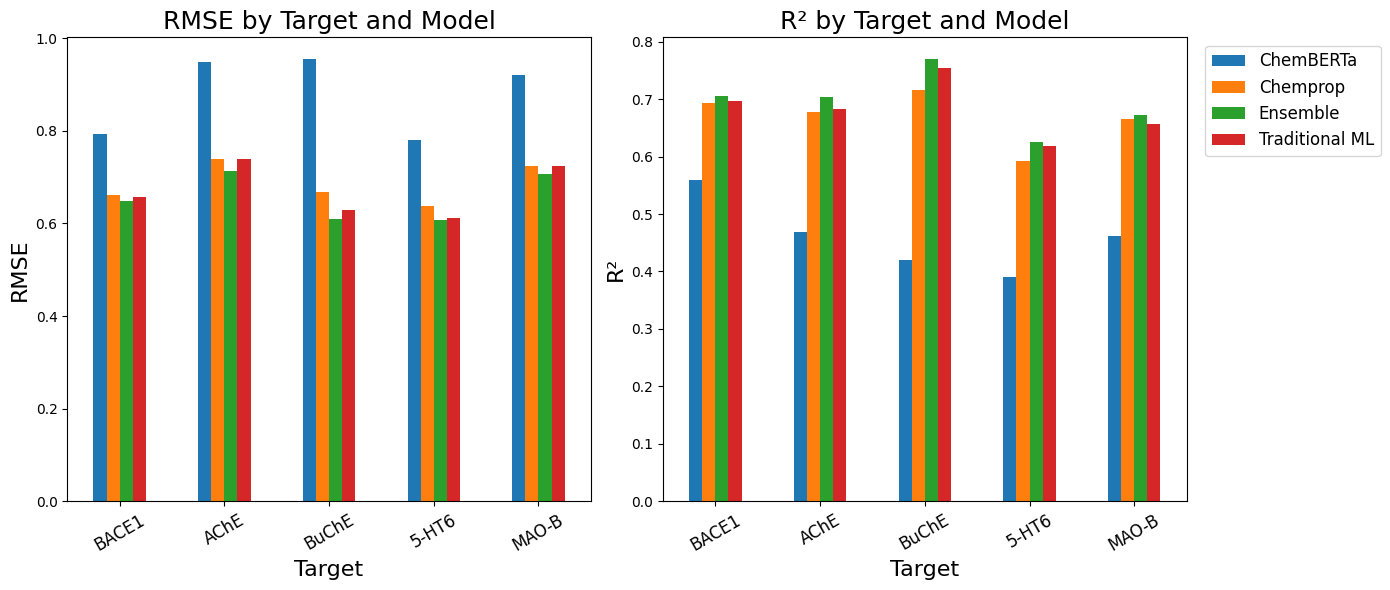

In [ ]:
target_order = ["BACE1", "AChE", "BuChE", "5-HT6", "MAO-B"]




def to_wide_metric(df, target_col="Target"):
    """Convert wide table (Target + model columns) into pivoted wide numeric table."""
    model_cols = [c for c in df.columns if c != target_col]
    long_df = df.melt(id_vars=[target_col], value_vars=model_cols,
                      var_name="Model", value_name="Value").copy()
    long_df["Value"] = pd.to_numeric(long_df["Value"], errors="coerce")
    long_df = long_df.dropna(subset=["Value"])
    wide = long_df.pivot_table(index=target_col, columns="Model", values="Value", aggfunc="mean")
    return wide.sort_index()

rmse_wide = to_wide_metric(df_rmse, target_col="Target").reindex(target_order)
r2_wide   = to_wide_metric(df_r2,   target_col="Target").reindex(target_order)

# --- Plot as two subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# RMSE subplot
rmse_wide.plot(kind="bar", ax=axes[0])
axes[0].set_title("RMSE by Target and Model", fontsize=18)
axes[0].set_xlabel("Target", fontsize=16)
axes[0].set_ylabel("RMSE", fontsize=16)
axes[0].tick_params(axis="x", rotation=30, labelsize=12)

# R² subplot
r2_wide.plot(kind="bar", ax=axes[1])
axes[1].set_title("R² by Target and Model", fontsize=18)
axes[1].set_xlabel("Target", fontsize=16)
axes[1].set_ylabel("R²", fontsize=16)
axes[1].tick_params(axis="x", rotation=30, labelsize=12)

# Put legends outside (cleaner)
axes[0].legend( bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=12)
axes[1].legend( bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=12)

axes[0].get_legend().remove()

plt.tight_layout()
plt.show()
